In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import pyreadr
import pickle
from tqdm import tqdm
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
from pathlib import Path

# ================================================================
# CONFIG
# ================================================================

BASE_DIR = Path(r"D:\77\Research\temp\snow")
period = 52
np.random.seed(123)

no_nbs = np.array([
    57,170,236,269,343,685,946,947,989,
    1037,1084,1090,1109,1118,1127,1176,1203
]) - 1

def sigmoid(z):
    z = np.clip(z, -30, 30)
    return 1/(1+np.exp(-z))

# ================================================================
# 1️⃣ LOAD DATA
# ================================================================

snow = pyreadr.read_r(BASE_DIR/"snow_cleaned_full.Rda")
snow = list(snow.values())[0].reset_index(drop=True)

coords_full = snow.iloc[:, :2].to_numpy()
y_full = snow.iloc[:, 2:].to_numpy()

coords = np.delete(coords_full, no_nbs, axis=0)
y = np.delete(y_full, no_nbs, axis=0)

# ================================================================
# 2️⃣ TWO LARGEST COMPONENTS
# ================================================================

gdf = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(coords[:,0], coords[:,1]),
    crs="EPSG:4326"
).to_crs("+proj=aeqd +lat_0=90 +lon_0=-100")

xy = np.vstack([gdf.geometry.x, gdf.geometry.y]).T / 1e6
D = squareform(pdist(xy))
W = (D <= 0.22).astype(int)
np.fill_diagonal(W, 0)
W = csr_matrix(W)

n_comp, labels = connected_components(W, directed=False)
sizes = np.bincount(labels)
order = np.argsort(sizes)[::-1]

use_idx = np.sort(np.concatenate([
    np.where(labels==order[0])[0],
    np.where(labels==order[1])[0]
]))

coords = coords[use_idx]
y = y[use_idx]

S, TT = y.shape
print("Using S =", S, "T =", TT)

# ================================================================
# 3️⃣ TREND + WEEK INDEX
# ================================================================

t_full = np.arange(1, TT+1)
t_scaled_full = (t_full - t_full.mean()) / t_full.std()
week_index = np.arange(TT) % 52

# ================================================================
# 4️⃣ COVARIATES (FILTERED)
# ================================================================

lat = coords[:,1]
lat = (lat - lat.mean()) / lat.std()

elev_raw = pd.read_csv(BASE_DIR/"curr_elev.csv").iloc[:,3].to_numpy()
elev = elev_raw[use_idx]
elev = (elev - elev.mean()) / elev.std()

snow_temp = pyreadr.read_r(BASE_DIR/"snow_temp_full.Rda")
snow_temp = list(snow_temp.values())[0].reset_index(drop=True)
temp_full = snow_temp.drop(index=no_nbs).iloc[:,2:].to_numpy()
temp = temp_full[use_idx]
temp = (temp - temp.mean()) / temp.std()

# ================================================================
# 5️⃣ LOAD POSTERIORS
# ================================================================

iid01 = np.load(BASE_DIR/"ind01.npz")["all_theta"]
iid10 = np.load(BASE_DIR/"ind10.npz")["all_theta"]

bym01 = np.load(BASE_DIR/"bym01.npz")["all_theta"]
bym10 = np.load(BASE_DIR/"bym10.npz")["all_theta"]

bym01_cov = np.load(BASE_DIR/"bym01_cov.npz")["all_theta"]
bym10_cov = np.load(BASE_DIR/"bym10_cov.npz")["all_theta"]

with open(BASE_DIR/"bym01_weekly.pkl","rb") as f:
    res_w01 = pickle.load(f)
with open(BASE_DIR/"bym10_weekly.pkl","rb") as f:
    res_w10 = pickle.load(f)

with open(BASE_DIR/"bym01_cov_weekly.pkl","rb") as f:
    res_wf01 = pickle.load(f)
with open(BASE_DIR/"bym10_cov_weekly.pkl","rb") as f:
    res_wf10 = pickle.load(f)

eta01_w  = res_w01["all_eta"]
tau01_w  = res_w01["all_tau"]
eta10_w  = res_w10["all_eta"]
tau10_w  = res_w10["all_tau"]

eta01_wf = res_wf01["all_eta"]
tau01_wf = res_wf01["all_tau"]
eta10_wf = res_wf10["all_eta"]
tau10_wf = res_wf10["all_tau"]

# ================================================================
# 6️⃣ SAMPLE 200 DRAWS
# ================================================================

M_total = iid01.shape[1]
draws = np.random.choice(M_total, 1000, replace=False)

# ================================================================
# 7️⃣ STORAGE
# ================================================================

iid_week   = np.zeros((S,52,1000))
bym_week   = np.zeros((S,52,1000))
fac_week   = np.zeros((S,52,1000))
scale_week = np.zeros((S,52,1000))
wf_week    = np.zeros((S,52,1000))

print("Running prediction...")

# ================================================================
# 8️⃣ MAIN LOOP
# ================================================================

for j,m in enumerate(tqdm(draws)):

    # ===============================
    # 1️⃣ IID
    # ===============================

    pi = np.zeros((S,TT))
    pi[:,0] = y[:,0]

    for t in range(1,TT):

        xvals = np.array([
            1,
            np.cos(2*np.pi*(t+1)/period),
            np.sin(2*np.pi*(t+1)/period),
            t_scaled_full[t]
        ])

        eta01 = sum(xvals[k]*iid01[k*S:(k+1)*S,m] for k in range(4))
        eta10 = sum(xvals[k]*iid10[k*S:(k+1)*S,m] for k in range(4))

        p01 = sigmoid(eta01)
        p10 = sigmoid(eta10)

        prev = y[:,t-1]
        pi[:,t] = (1-prev)*p01 + prev*(1-p10)

    for w in range(52):
        iid_week[:,w,j] = pi[:,week_index==w].mean(axis=1)

    # ===============================
    # 2️⃣ BYM SHARED
    # ===============================

    pi = np.zeros((S,TT))
    pi[:,0] = y[:,0]

    for t in range(1,TT):

        xvals = np.array([
            1,1,
            np.cos(2*np.pi*(t+1)/period),
            np.cos(2*np.pi*(t+1)/period),
            np.sin(2*np.pi*(t+1)/period),
            np.sin(2*np.pi*(t+1)/period),
            t_scaled_full[t],
            t_scaled_full[t]
        ])

        eta01 = sum(xvals[k]*bym01[k*S:(k+1)*S,m] for k in range(8))
        eta10 = sum(xvals[k]*bym10[k*S:(k+1)*S,m] for k in range(8))

        p01 = sigmoid(eta01)
        p10 = sigmoid(eta10)

        prev = y[:,t-1]
        pi[:,t] = (1-prev)*p01 + prev*(1-p10)

    for w in range(52):
        bym_week[:,w,j] = pi[:,week_index==w].mean(axis=1)

    # ===============================
    # 3️⃣ BYM + COV
    # ===============================

    pi = np.zeros((S,TT))
    pi[:,0] = y[:,0]

    g01 = bym01_cov[8*S:8*S+3,m]
    g10 = bym10_cov[8*S:8*S+3,m]

    for t in range(1,TT):

        xvals = np.array([
            1,1,
            np.cos(2*np.pi*(t+1)/period),
            np.cos(2*np.pi*(t+1)/period),
            np.sin(2*np.pi*(t+1)/period),
            np.sin(2*np.pi*(t+1)/period),
            t_scaled_full[t],
            t_scaled_full[t]
        ])

        eta01 = sum(xvals[k]*bym01_cov[k*S:(k+1)*S,m] for k in range(8))
        eta10 = sum(xvals[k]*bym10_cov[k*S:(k+1)*S,m] for k in range(8))

        fac = np.column_stack([
            t_scaled_full[t]*lat,
            t_scaled_full[t]*elev,
            t_scaled_full[t]*temp[:,t]
        ])

        eta01 += fac @ g01
        eta10 += fac @ g10

        p01 = sigmoid(eta01)
        p10 = sigmoid(eta10)

        prev = y[:,t-1]
        pi[:,t] = (1-prev)*p01 + prev*(1-p10)

    for w in range(52):
        fac_week[:,w,j] = pi[:,week_index==w].mean(axis=1)

    # ===============================
    # 4️⃣ WEEKLY SCALING
    # ===============================

    pi = np.zeros((S,TT))
    pi[:,0] = y[:,0]

    for t in range(1,TT):

        w = week_index[t]

        xvals = np.array([
            1,1,
            np.cos(2*np.pi*(t+1)/period),
            np.cos(2*np.pi*(t+1)/period),
            np.sin(2*np.pi*(t+1)/period),
            np.sin(2*np.pi*(t+1)/period),
            t_scaled_full[t],
            t_scaled_full[t]
        ])

        eta01 = sum(
            xvals[k] * eta01_w[k*S:(k+1)*S,m] * tau01_w[k*52+w,m]
            for k in range(8)
        )

        eta10 = sum(
            xvals[k] * eta10_w[k*S:(k+1)*S,m] * tau10_w[k*52+w,m]
            for k in range(8)
        )

        p01 = sigmoid(eta01)
        p10 = sigmoid(eta10)

        prev = y[:,t-1]
        pi[:,t] = (1-prev)*p01 + prev*(1-p10)

    for w in range(52):
        scale_week[:,w,j] = pi[:,week_index==w].mean(axis=1)

    # ===============================
    # 5️⃣ WEEKLY + COV
    # ===============================

    pi = np.zeros((S,TT))
    pi[:,0] = y[:,0]

    g01 = eta01_wf[8*S:8*S+3,m]
    g10 = eta10_wf[8*S:8*S+3,m]

    for t in range(1,TT):

        w = week_index[t]

        xvals = np.array([
            1,1,
            np.cos(2*np.pi*(t+1)/period),
            np.cos(2*np.pi*(t+1)/period),
            np.sin(2*np.pi*(t+1)/period),
            np.sin(2*np.pi*(t+1)/period),
            t_scaled_full[t],
            t_scaled_full[t]
        ])

        eta01 = sum(
            xvals[k] * eta01_wf[k*S:(k+1)*S,m] * tau01_wf[k*52+w,m]
            for k in range(8)
        )

        eta10 = sum(
            xvals[k] * eta10_wf[k*S:(k+1)*S,m] * tau10_wf[k*52+w,m]
            for k in range(8)
        )

        fac = np.column_stack([
            t_scaled_full[t]*lat,
            t_scaled_full[t]*elev,
            t_scaled_full[t]*temp[:,t]
        ])

        eta01 += fac @ g01
        eta10 += fac @ g10

        p01 = sigmoid(eta01)
        p10 = sigmoid(eta10)

        prev = y[:,t-1]
        pi[:,t] = (1-prev)*p01 + prev*(1-p10)

    for w in range(52):
        wf_week[:,w,j] = pi[:,week_index==w].mean(axis=1)

print("Done.")

Using S = 1557 T = 2704
Running prediction...


100%|██████████| 1000/1000 [1:30:49<00:00,  5.45s/it]

Done.


In [2]:
def summarize(x):
    mean = x.mean(axis=2)
    lo   = np.quantile(x, 0.05, axis=2)
    hi   = np.quantile(x, 0.95, axis=2)
    return mean, lo, hi

iid_mean, iid_lo, iid_hi       = summarize(iid_week)
bym_mean, bym_lo, bym_hi       = summarize(bym_week)
fac_mean, fac_lo, fac_hi       = summarize(fac_week)
scale_mean, scale_lo, scale_hi = summarize(scale_week)
wf_mean, wf_lo, wf_hi          = summarize(wf_week)

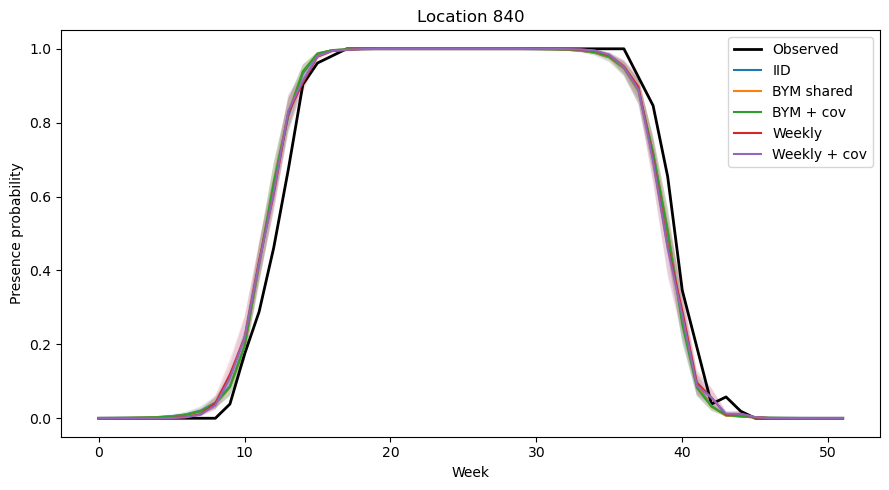

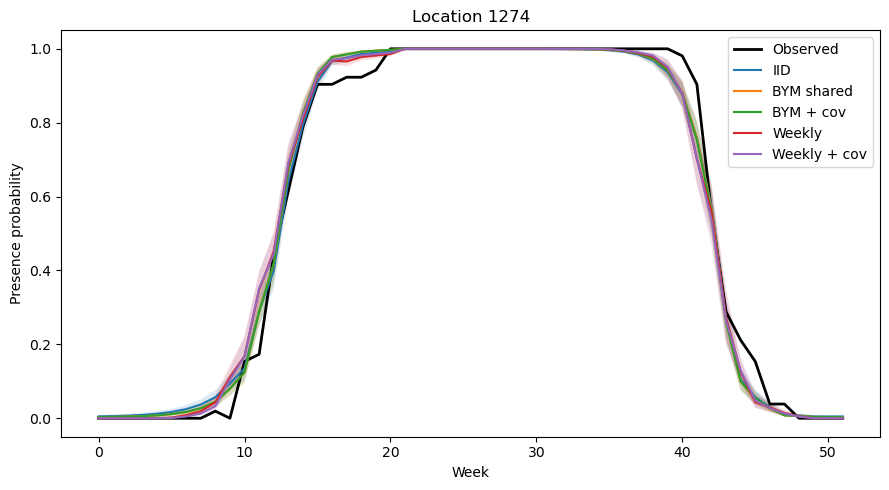

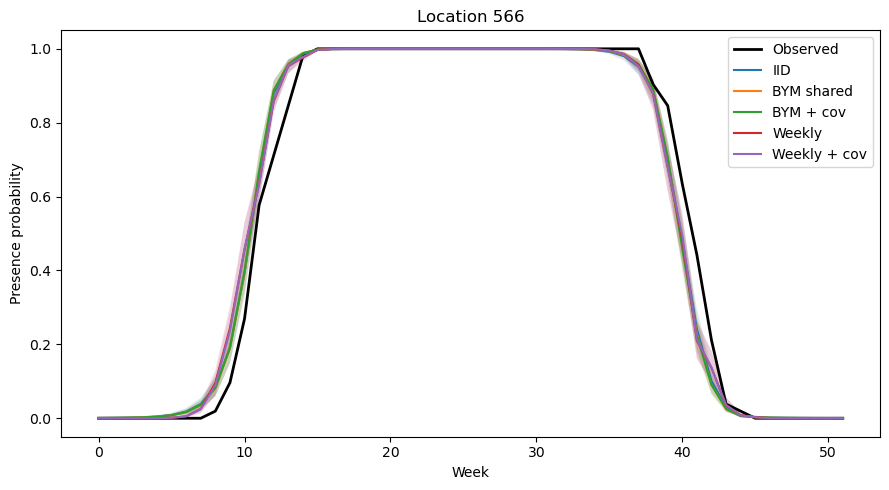

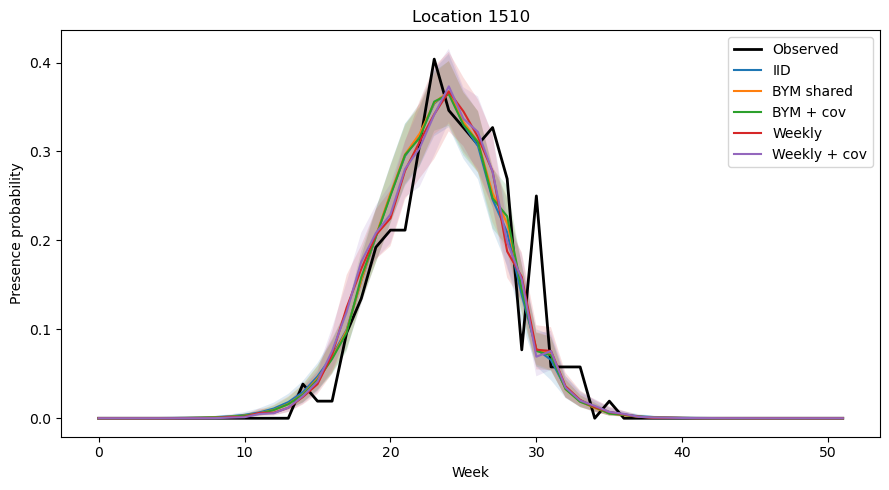

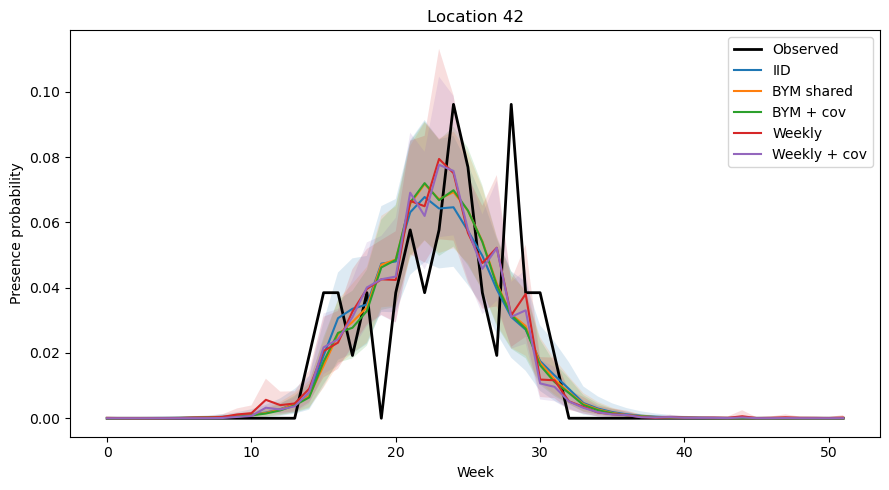

In [5]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(123)

obs_week = np.zeros((S,52))

for w in range(52):
    obs_week[:,w] = y[:,week_index==w].mean(axis=1)
    
    
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(123)

locs = np.random.choice(S, 5, replace=False)
weeks = np.arange(52)

for s in locs:

    plt.figure(figsize=(9,5))

    # Observed
    plt.plot(weeks, obs_week[s],
             color="black", linewidth=2, label="Observed")

    # IID
    plt.plot(weeks, iid_mean[s], label="IID")
    plt.fill_between(weeks, iid_lo[s], iid_hi[s], alpha=0.15)

    # BYM shared
    plt.plot(weeks, bym_mean[s], label="BYM shared")
    plt.fill_between(weeks, bym_lo[s], bym_hi[s], alpha=0.15)

    # BYM + cov
    plt.plot(weeks, fac_mean[s], label="BYM + cov")
    plt.fill_between(weeks, fac_lo[s], fac_hi[s], alpha=0.15)

    # Weekly scaling
    plt.plot(weeks, scale_mean[s], label="Weekly")
    plt.fill_between(weeks, scale_lo[s], scale_hi[s], alpha=0.15)

    # Weekly + cov
    plt.plot(weeks, wf_mean[s], label="Weekly + cov")
    plt.fill_between(weeks, wf_lo[s], wf_hi[s], alpha=0.15)

    plt.title(f"Location {s}")
    plt.xlabel("Week")
    plt.ylabel("Presence probability")
    plt.legend()
    plt.tight_layout()
    plt.show()